<a href="https://colab.research.google.com/github/dee0742/ML-FlyRank-Task/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dee0742/ML-FlyRank-Task/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The action queue ranks content items so that a human reviewer can decide which items to examine first.

A higher action score means that the item is placed earlier in the review queue. It does not mean that the recommended action will improve performance.

The reason codes make the ranking easier to understand:

* **STALE_HIGH_DEMAND** — the content is at least 180 days old and has search volume of at least 500. Suggested action: review the page for a possible refresh.
* **STALE_LOW_DEMAND** — the content is at least 180 days old but has lower or missing search volume. Suggested action: monitor unless a reviewer sees another reason to act.
* **FRESH_HIGH_DEMAND** — the content is less than 180 days old and has search volume of at least 500. Suggested action: review the page for possible issues.
* **FRESH_LOW_DEMAND** — the content is relatively fresh and has lower or missing search volume. Suggested action: monitor.

The reason codes are descriptive signals, not causal explanations. They help a reviewer understand why an item entered the queue.

The queue is therefore a decision-support tool. It recommends what may be worth reviewing first, but a person decides whether any action should be taken.


In [1]:
import numpy as np
import pandas as pd

# Load the dataset
df = pd.read_csv(
    "https://raw.githubusercontent.com/dee0742/ML-FlyRank-Task/main/data/raw/content_refresh_anonymized.csv"
)

print("Dataset shape:", df.shape)

# ---------------------------------------------------------
# 1. Create the action score
# ---------------------------------------------------------

# Higher values mean the content is more stale
staleness_score = df["days_since_last_update"].rank(
    pct=True,
    na_option="bottom"
)

# Higher values mean greater search demand
demand_score = df["search_volume"].rank(
    pct=True,
    na_option="bottom"
)

# Simple transparent baseline score
df["action_score"] = (
    0.5 * staleness_score
    + 0.5 * demand_score
)

# ---------------------------------------------------------
# 2. Create reason codes
# ---------------------------------------------------------

stale = df["days_since_last_update"] >= 180
high_demand = df["search_volume"].fillna(0) >= 500

df["reason_code"] = np.select(
    [
        stale & high_demand,
        stale & ~high_demand,
        ~stale & high_demand
    ],
    [
        "STALE_HIGH_DEMAND",
        "STALE_LOW_DEMAND",
        "FRESH_HIGH_DEMAND"
    ],
    default="FRESH_LOW_DEMAND"
)

# ---------------------------------------------------------
# 3. Map reason codes to suggested actions
# ---------------------------------------------------------

df["action"] = df["reason_code"].map({
    "STALE_HIGH_DEMAND": "REVIEW_REFRESH",
    "STALE_LOW_DEMAND": "MONITOR",
    "FRESH_HIGH_DEMAND": "REVIEW_DIAGNOSTIC",
    "FRESH_LOW_DEMAND": "MONITOR"
})

# ---------------------------------------------------------
# 4. Rank the queue
# ---------------------------------------------------------

queue = (
    df.sort_values(
        "action_score",
        ascending=False
    )
    .reset_index(drop=True)
)

queue["rank"] = queue.index + 1

# ---------------------------------------------------------
# 5. Select reviewer-friendly columns
# ---------------------------------------------------------

queue = queue[
    [
        "rank",
        "content_id",
        "action_score",
        "reason_code",
        "action",
        "days_since_last_update",
        "search_volume",
        "content_type",
        "main_intent"
    ]
]

# ---------------------------------------------------------
# 6. Display results
# ---------------------------------------------------------

print("\nTop 20 ranked actions:")
display(queue.head(20))

print("\nReason-code counts:")
display(
    queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

Dataset shape: (30000, 44)

Top 20 ranked actions:


,rank,content_id,action_score,reason_code,action,days_since_last_update,search_volume,content_type,main_intent
0,1,content_f01216059a6a,0.979358,STALE_LOW_DEMAND,MONITOR,335,NaN,keyword article,NaN
1,2,content_e2b702f4f92b,0.979333,STALE_LOW_DEMAND,MONITOR,334,NaN,keyword article,NaN
2,3,content_06e19c6486b0,0.979333,STALE_LOW_DEMAND,MONITOR,334,NaN,keyword article,NaN
3,4,content_f488400fca67,0.979167,STALE_LOW_DEMAND,MONITOR,305,NaN,keyword article,NaN
4,5,content_df1fa766cac2,0.979033,STALE_LOW_DEMAND,MONITOR,304,NaN,keyword article,NaN
5,6,content_07ce98c6085a,0.979033,STALE_LOW_DEMAND,MONITOR,304,NaN,keyword article,NaN
6,7,content_15fe075b97bc,0.979033,STALE_LOW_DEMAND,MONITOR,304,NaN,keyword article,NaN
7,8,content_ab27c30d81f4,0.979033,STALE_LOW_DEMAND,MONITOR,304,NaN,keyword article,NaN
8,9,content_84d12054c0c0,0.979033,STALE_LOW_DEMAND,MONITOR,304,NaN,keyword article,NaN
9,10,content_7736e6144f3b,0.979033,STALE_LOW_DEMAND,MONITOR,304,NaN,keyword article,NaN



Reason-code counts:


,reason_code,count
0,FRESH_LOW_DEMAND,28800
1,FRESH_HIGH_DEMAND,1026
2,STALE_LOW_DEMAND,172
3,STALE_HIGH_DEMAND,2


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

The playbook is intended for content analysts, SEO teams, or researchers who need a prioritized list of content items for human review.

Its main purpose is to reduce the amount of content that needs to be checked manually by putting higher-priority candidates near the top of the queue.

The ranking should be used as decision-support, not as an automatic content management system. A high score means that an item deserves earlier review; it does not guarantee that the page needs a refresh or that a refresh will improve its performance.

The analysis is based on the available dataset and observed content and performance variables. The results should therefore be treated as directional evidence for this dataset and evaluation period.

The playbook should not be used to claim that content age, word count, or any other feature causes a change in search performance. It also should not be treated as proof that the same ranking performance will hold for every future client, website, topic, or search environment.

Human review is required before making a content change.


In [2]:
# Basic checks supporting the intended-use statement

print("Number of content items:", len(queue))
print("Number of unique content items:", queue["content_id"].nunique())

print("\nAction distribution:")
display(
    queue["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

print("\nMissing values in reviewer fields:")
display(
    queue[
        [
            "days_since_last_update",
            "search_volume",
            "content_type",
            "main_intent"
        ]
    ].isna().sum()
)

Number of content items: 30000
Number of unique content items: 30000

Action distribution:


,action,count
0,MONITOR,28972
1,REVIEW_DIAGNOSTIC,1026
2,REVIEW_REFRESH,2



Missing values in reviewer fields:


,0
days_since_last_update,0
search_volume,2468
content_type,0
main_intent,2374


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Every ranked item must be checked by a human before any content change is made.

The reviewer should check:

1. Whether the page is still relevant to the intended search topic.
2. Whether the information is outdated or incorrect.
3. Whether the search intent has changed.
4. Whether important competitors or current search results have changed.
5. Whether the page already has recent updates that are not fully represented in the dataset.
6. Whether the page has business, legal, medical, brand, or other risks that require specialist review.
7. Whether the recommended action is practical and has enough expected value to justify the work.

The ranking should not automatically publish, rewrite, delete, redirect, or substantially change content.

The following are no-go cases for automation:

* Automatically publishing rewritten content.
* Automatically deleting or redirecting pages.
* Automatically changing important factual, legal, medical, or financial claims.
* Automatically changing content strategy based only on the model score.
* Treating the score as proof of causality.
* Automatically applying the same action to every page in an archetype.
* Making decisions when required input data is missing or clearly stale.

The system should only prioritize items for review. The final action remains a human decision.


In [3]:
# Check how many queue items have missing fields
review_fields = [
    "days_since_last_update",
    "search_volume",
    "content_type",
    "main_intent"
]

missing_review_data = queue[review_fields].isna().any(axis=1)

print(
    "Items with at least one missing reviewer field:",
    missing_review_data.sum()
)

print(
    "Percentage with missing reviewer data:",
    round(missing_review_data.mean() * 100, 2),
    "%"
)

Items with at least one missing reviewer field: 2610
Percentage with missing reviewer data: 8.7 %


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The playbook should be checked periodically because content performance, search demand, and the underlying data can change.

The following are practical monitoring triggers:

* The distribution of the action score changes substantially from the reference dataset.
* Important input fields develop a high missing-value rate.
* The observed decline-label rate changes substantially from the reference period.
* Precision@K falls below the previously measured validation result when evaluated on a new labelled period.
* New clients or content types appear that were not represented in the original validation data.
* The relationship between the ranking and the observed decline label changes over time.

A new model or ranking method should only be considered after checking whether the change is caused by data quality, population shift, or a genuine change in performance.

Retraining should therefore be triggered by measured evidence of degradation or meaningful changes in the data, rather than by a fixed assumption that the model automatically becomes wrong after a certain number of days.

These checks are monitoring and research triggers, not production alerting rules.


In [4]:
# ---------------------------------------------------------
# Monitoring snapshot
# ---------------------------------------------------------

monitoring = {
    "rows": len(df),
    "missing_search_volume_rate": df["search_volume"].isna().mean(),
    "missing_update_date_rate": df["days_since_last_update"].isna().mean(),
    "decline_label_rate": (
        df["trend_direction"].astype(str).str.lower() == "down"
    ).mean(),
    "median_action_score": df["action_score"].median()
}

monitoring_df = pd.DataFrame(
    [monitoring]
)

display(monitoring_df)

print("These values form a simple reference snapshot.")

,rows,missing_search_volume_rate,missing_update_date_rate,decline_label_rate,median_action_score
0,30000,0.082267,0.0,0.542067,0.51395


These values form a simple reference snapshot.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The ranked queue is exported so that the recommendations section of the research paper can use the same output produced by this notebook.

The export contains the content identifier, ranking, action score, reason code, suggested action, and the main fields needed for human review.

The queue CSV is treated as a generated output rather than a source of manually edited results. Running the notebook again should regenerate the queue from the underlying data.

A summary figure is also exported so that the paper can describe the distribution of recommended actions without manually copying values from the notebook.


Queue exported to: work/outputs/action_playbook_queue.csv
Summary exported to: work/outputs/action_archetype_summary.csv


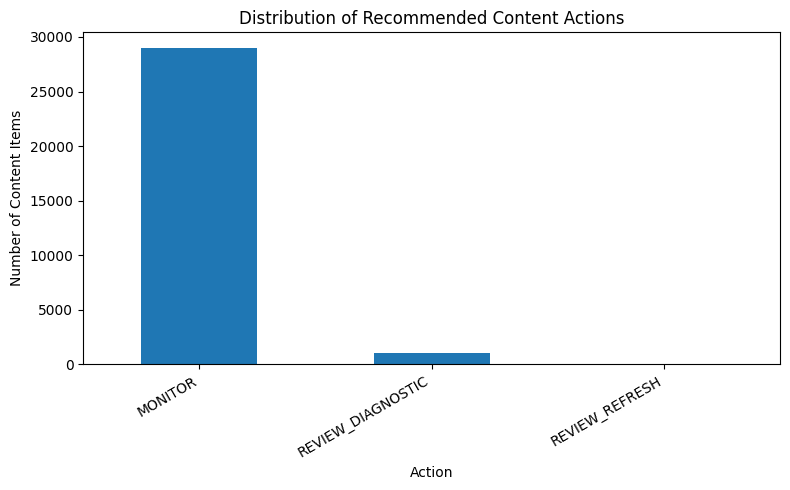

Figure exported to: work/figures/action_distribution.png


In [5]:
import os
import matplotlib.pyplot as plt

# Create output folders
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# ---------------------------------------------------------
# 1. Export ranked queue
# ---------------------------------------------------------

queue_path = "work/outputs/action_playbook_queue.csv"

queue.to_csv(
    queue_path,
    index=False
)

print("Queue exported to:", queue_path)

# ---------------------------------------------------------
# 2. Export archetype/action summary
# ---------------------------------------------------------

action_summary = (
    queue.groupby(["reason_code", "action"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

summary_path = "work/outputs/action_archetype_summary.csv"

action_summary.to_csv(
    summary_path,
    index=False
)

print("Summary exported to:", summary_path)

# ---------------------------------------------------------
# 3. Create figure
# ---------------------------------------------------------

action_counts = (
    queue["action"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

action_counts.plot(kind="bar")

plt.title("Distribution of Recommended Content Actions")
plt.xlabel("Action")
plt.ylabel("Number of Content Items")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

figure_path = "work/figures/action_distribution.png"

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Figure exported to:", figure_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.